# Лабораторная работа №5. <br> Анимация качения треугольника Рело по квадрату

## Задание 5.1. Начальное положение треугольника Рело и квадрата

**Поступательное движение фигуры** – это движение, при котором траектории движения всех точек фигуры одинаковы.

**Вращательное движение фигуры** – это движение, при котором траектории движения точек фигуры представляют собой окружности (или дуги окружностей) с центрами, лежащими в одной точке.

**Качение треугольника Рело по квадрату** – это вращательное движение треугольника Рело относительно своего центра с дополнительным поступательным движением центра треугольника по траектории, близкой к окружности, чтобы
обеспечить касание всех сторон квадрата при движении треугольника Рело. Качение треугольника Рело происходит за счет его одновременного поступательного и вращательного движения.

Полагаем, что при качении по квадрату против часовой стрелки центр треугольника Рело совершает поступательное движение по окружности против часовой стрелки с центром окружности, расположенным в начале координат. Радиус окружности для поступательного движения является неизвестным и будет вычислен в Задании 5.1.

Одновременно с поступательным движением треугольник Рело совершает вращательное движение по часовой стрелке. Поступательное и вращательное движения согласованы таким образом, что поступательное движение по всей окружности соответствует вращательному движению треугольника Рело на угол $\frac{2\pi}{3}$.

**Для упрощения моделирования принимаются следующие допущения:**
1) Движение без проскальзывания – точка контакта треугольника и квадрата мгновенно неподвижна (качение происходит без трения);
2) Поступательное движение центра – центр треугольника движется равномерно вдоль сторон квадрата;
3) Дискретные повороты на 120° – при переходе между сторонами квадрата треугольник мгновенно поворачивается, сохраняя контакт с новой стороной;
4) Постоянная ширина треугольника – расстояние между любыми двумя параллельными опорными прямыми равно стороне исходного равностороннего треугольника;
5) Идеальная форма квадрата – стороны строго прямые, углы — 90°.

Импортируем необходимые для работы модули:

In [1]:
#Импортируем модули, для работы с данными;
import numpy as np
import relo
import matplotlib.pyplot as plt

Определим **исходные данные** для построения треугольника Рело:

In [2]:
n = 3
center = np.array([0., 0.])
r = 10.
N = 100

Зададим матрицу $relo_matrix$ координат точек-границ треугольника Рело:

In [3]:
relo_matrix = relo.regular_polygon_Relo(n, center, r, N)

Теперь зададим матрицу $square$ координат точек-границ квадрата:

In [4]:
angleList = np.arange(0, 2 * np.pi, np.pi / 2)
square = center + r * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                      np.sign(np.sin(angleList + np.pi / 4))])

#Добавляем ещё одну точку в конец, чтобы квадрат замыкался;
square = np.vstack([square, square[0]]) 

Изобразим в одной графической области **квадрат, описанный около треугольника Рело, сам треугольник Рело и точку центра**:

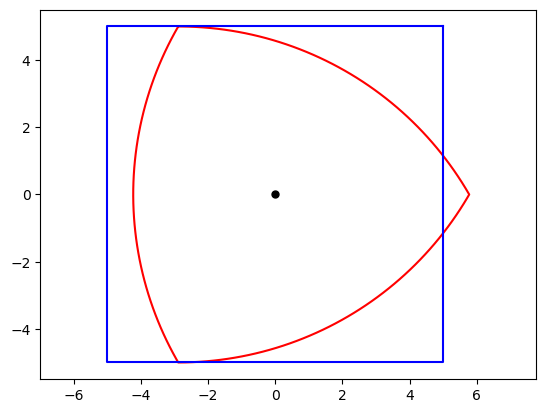

In [5]:
plt.plot(relo_matrix[:,0], relo_matrix[:,1], 'r-')

#Добавляем ещё одну точку в конец, чтобы квадрат замыкался;
plt.plot(square[:,0], square[:,1], 'b-')
plt.plot(center[0], center[1], 'k.', markersize = 10)

plt.axis('equal')
plt.show()



**Рассмотрим правильный треугольник Рело**. Можно заметить, что его вершины находятся на окружности радиуса $R$. Квадрат же был построен исходя из значения **половины ширины правильного треугольника Рело $\frac{r}{2}$**. Поэтому, чтобы определить сдвиг $shift$, на который нужно переместить треугольник Рело, чтобы он оказался вписан в квадрат, достаточно найти разность между $R$ и $\frac{r}{2}$:
<b>$$\text{shift} = R - \frac{r}{2}$$

Из лабораторной работы 3 мы знаем, что формула для нахождения радиуса описанной вокруг правильного треугольника Рело равна:
$$R = \frac{r}{2 \sin(\frac{\pi}{n})}$$

Подставив в **(1)** получим:
$$\text{shift} = \frac{r}{2 \sin(\frac{\pi}{n})} - \frac{r}{2} = \frac{r}{2}(\frac{1}{\sin(\frac{\pi}{n})} - 1)$$

**<p style = "background-color: #e5f4ff; text-align: center;">Реализация:</p>**

In [6]:
#Определяем сдвиг и применяем его;
shift = np.array([r * 0.5 * (1 / np.sin(np.pi / n) - 1), 0])
relo_matrix_shifted = relo_matrix - shift
center -= shift

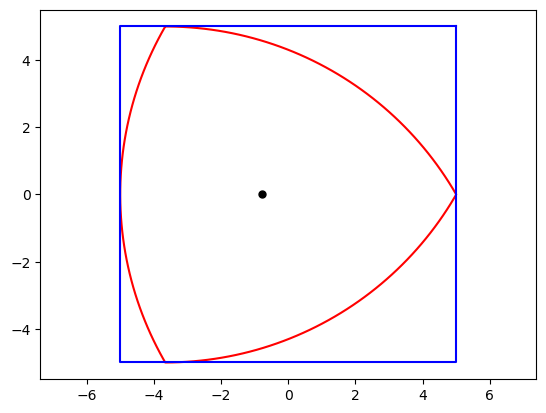

In [7]:
plt.plot(relo_matrix_shifted[:,0], relo_matrix_shifted[:,1], 'r-')
plt.plot(square[:,0], square[:,1], 'b-')
plt.plot(center[0], center[1], 'k.', markersize = 10)

plt.axis('equal')
plt.show()

## Задание 5.2. Анимация поступательного движения треугольника Рело по окружности 

Зададим количество кадров анимации $N_frames$, **необходимое для поступательного движения треугольника с полным обходом окружности**:

In [8]:
N_frames = 100

Создадим матрицу **center_frame** из **N_frames** строк и двух столбцов для описания координат точек окружности, необходимой для реализации поступательного движения:

In [9]:
t_center = np.linspace(-np.pi, np.pi, N_frames)
center_frame = shift[0] * np.transpose([np.cos(t_center), np.sin(t_center)])

Изобразим первый кадр анимации:

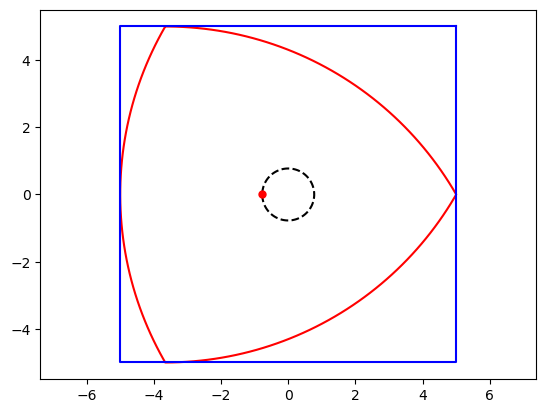

In [10]:
#Задаем данные для первого кадра анимации;
frame = 0
relo_matrix_shifted = relo_matrix + center_frame[frame]

#Отображаем в одной графической области все фигуры: квадрат, треугольник рело,
#центральную точку и окружность, по которой она будет двигаться;
plt.figure()

plt.plot(relo_matrix_shifted[:,0], relo_matrix_shifted[:,1], 'r-')
plt.plot(square[:,0], square[:,1], 'b-')
plt.plot(center_frame[:,0], center_frame[:,1], 'k--')
plt.plot(center_frame[frame, 0], center_frame[frame, 1], 'r.', markersize=10)

plt.axis('equal');

### Создание функции draw_frame 

Напишем пользовательскую функцию трех аргументов **draw_frame(r, N_frames, frame)**, которая изображает кадр с номером $frame$ при поступательном движении центра треугольника Рело по окружности против часовой стрелки:

In [11]:
def draw_frame(r: float = 10., 
              N_frames: int = 100, 
              frame: int = 0) -> None:
    
    """
    Изображает кадр с номером frame при поступательном движении центра треугольника 
    Рело по окружности против часовой стрелки.

    Параметры:
        r (float): Ширина треугольника (по умолчанию 10);
        N_frames (int): Общее число кадров анимации (по умолчанию 100);
        frame (int): Номер текущего кадра (по умолчанию 0);
        center (np.ndarray): Центр фигуры (по умолчанию np.array([0, 0]));
        N (int): Число точек на дуге (по умолчанию 100).

    Возвращает:
        Функция осуществляет визуализацию и не возвращает объекты.
    """

    #Создаем переменные, которые пригодятся в реализации визуализации;
    n = 3
    center = np.array([0., 0.]) 
    N = 100
    
    #Создаем матрицу координат точек сторон правильного треугольника Рело;
    relo_matrix = relo.regular_polygon_Relo(n, center, r, N)
    
    #Создаем матрицу координат вершин квадрата;
    angleList = np.arange(0, 2 * np.pi, np.pi / 2)
    square = center + r * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                          np.sign(np.sin(angleList + np.pi / 4))])
    square = np.vstack([square, square[0]])

    #Определяем сдвиг и создаем матрицу координат окружности;;
    shift = np.array([r * 0.5 * (1 / np.sin(np.pi / n) - 1), 0])
    t_center = np.linspace(-np.pi, np.pi, N_frames)
    center_frame = shift[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
    
    #Новая матрица координат;
    relo_matrix_shifted = relo_matrix + center_frame[frame]
    
    #Отображаем фигуры в одной графической области;       
    plt.plot(relo_matrix_shifted[:,0], relo_matrix_shifted[:,1], 'r-')
    plt.plot(square[:,0], square[:,1], 'b-')
    plt.plot(center_frame[:,0], center_frame[:,1], 'k--')
    plt.plot(center_frame[frame, 0], center_frame[frame, 1], 'r.', markersize=10)

    plt.axis('equal')

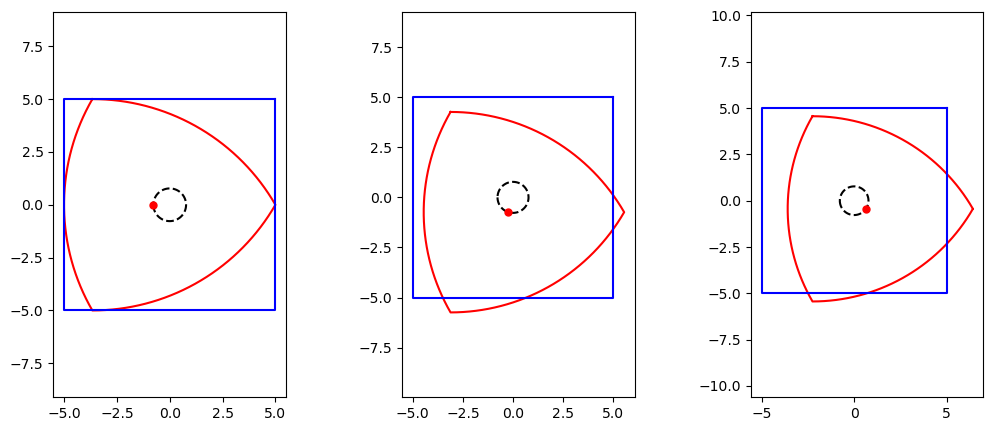

In [12]:

plt.figure(figsize = (12, 5))
plt.subplots_adjust(wspace = 0.5)

N_frames = 100
plt.subplot(1,3,1)
draw_frame(r = r, N_frames = N_frames)
plt.subplot(1,3,2)
draw_frame(r = r, N_frames = N_frames, frame = 20)
plt.subplot(1,3,3)
draw_frame(r = r, N_frames = N_frames, frame = 40)

### Анимации поступательного движения треугольника Рело

In [13]:
# Импортируем модули, который нужен для анимации;
from matplotlib.animation import FuncAnimation

#Корректируем отображение анимации;
%matplotlib widget

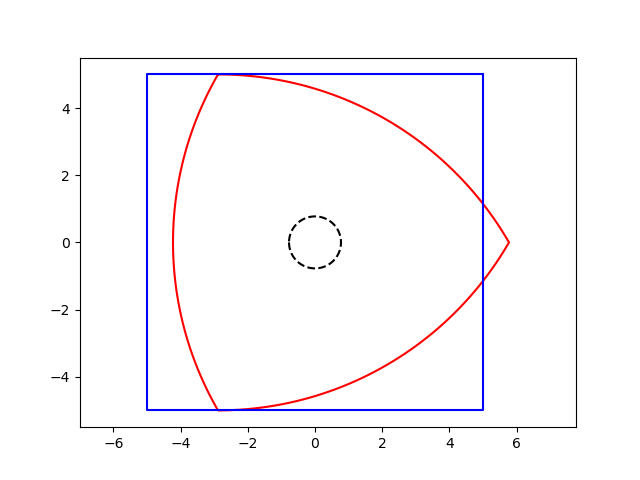

In [18]:
fig1 = plt.figure()
ax1 = plt.axes()


def init():
    global line, reloTriangle, relo_matrix, center_frame
    
    #Создаем переменные;
    n, N = 3, 100
    r, N_frames = 10., 100
    center = np.array([0., 0.]) 
    
    #Создаем матрицу координат точек сторон правильного треугольника Рело;
    relo_matrix = relo.regular_polygon_Relo(n, center, r, N)
    
    #Создаем матрицу координат вершин квадрата;
    angleList = np.arange(0, 2 * np.pi, np.pi / 2)
    square = center + r * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                          np.sign(np.sin(angleList + np.pi / 4))])
    square = np.vstack([square, square[0]])

    #Определяем сдвиг и создаем матрицу координат окружности;
    shift = np.array([r * 0.5 * (1 / np.sin(np.pi / n) - 1), 0])
    t_center = np.linspace(-np.pi, np.pi, N_frames)
    center_frame = shift[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
    
    #Отображаем фигуры в одной графической области; 
    ax1.clear()
    
    reloTriangle, = ax1.plot(relo_matrix[:, 0], relo_matrix[:, 1], 'r-', markersize = 15)
    ax1.plot(square[:, 0], square[:, 1], 'b-')
    ax1.plot(center_frame[:, 0], center_frame[:, 1], 'k--')
    line, = ax1.plot([], [],'r.', markersize = 10)
    
    ax1.axis('equal')
    

def atFrame(frame):
    newrelo_matrix = relo_matrix + center_frame[frame]
    
    reloTriangle.set_data(newrelo_matrix[:, 0], newrelo_matrix[:, 1])
    line.set_data([center_frame[frame, 0]], [center_frame[frame, 1]])


init()

FuncAnimation(fig1, atFrame, frames = len(center_frame), init_func = init, repeat = False, interval = 20)

In [19]:
plt.close('all')

## Задание 5.3. Анимация качения треугольника Рело

Дополнительно к поступательному движению треугольника Рело против часовой стрелки добавим вращательное движение по часовой стрелке на угол $\theta$. При этом будем учитывать, что полный оборот центра треугольника на угол $2\pi$ соответствует вращению треугольника Рело на угол $\frac{2\pi}{3}$

Определим пользовательскую функцию **rotate_matrix(theta)** для создания матрицы поворота по часовой стрелке на угол $\theta$ с применение синтаксиса **lambda-функций**:

In [20]:
rotate_matrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
                                         [-np.sin(theta), np.cos(theta)]])

rotate_matrix(np.pi)

array([[-1.0000000e+00,  1.2246468e-16],
       [-1.2246468e-16, -1.0000000e+00]])

**Для поворота треугольника Рело** на заданный угол необходимо матрицу поворота умножить на каждую точку в представлении треугольника Рело $relo_matrix$ с центром в начале координат. Для умножения матрицы на вектор используем функцию **dot** из расширения **numpy**.

Например, повернем треугольник Рело $relo_matrix$ с центром в начале координат на угол $\frac{\pi}{3}$ по часовой стрелке.


In [21]:
theta = np.pi / 3
matrix = rotate_matrix(theta)

relo_matrixRotated = np.array([np.dot(matrix, row) for row in relo_matrix])


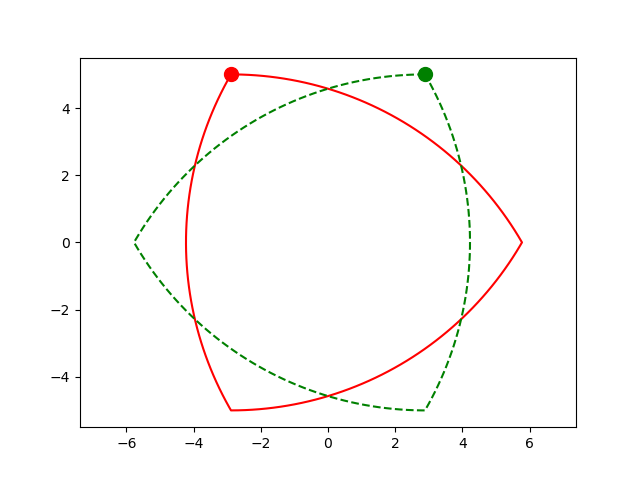

In [22]:
plt.figure()

plt.plot(relo_matrix[:,0], relo_matrix[:,1], 'r-')
plt.plot(relo_matrix[0, 0], relo_matrix[0, 1], 'r.', markersize=20)
plt.plot(relo_matrixRotated[:, 0], relo_matrixRotated[:, 1], 'g--')
plt.plot(relo_matrixRotated[0, 0], relo_matrixRotated[0, 1], 'g.', markersize=20)

plt.axis('equal');

Определим массив **theta** со значениями угла поворота при вращательном движении, согласованный с полным оборотом центра треугольника Рело за **N_frames** кадров.

In [23]:
theta = np.linspace(0, 2 * np.pi / 3, N_frames)

Изобразим 20-й кадр анимации:

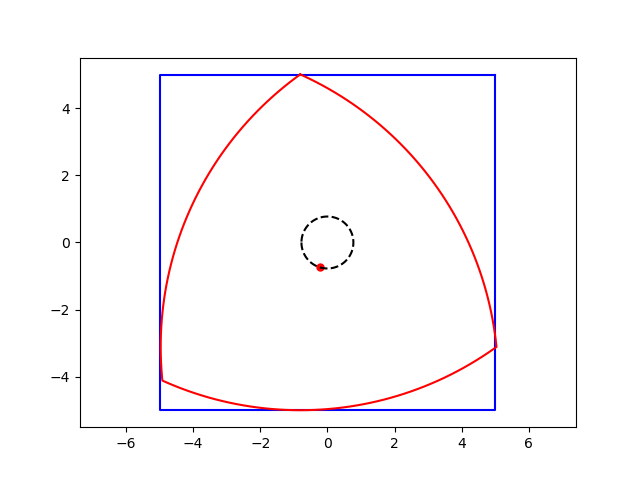

In [24]:
#Определяем 20-й кадр анимации;
frame = 20

#Значала поворачиваем треугольник, а после смещаем на вектор;
matrix = rotate_matrix(theta[frame])
relo_matrixChanged = (np.array([np.dot(matrix,row) for row in relo_matrix]) 
                     + center_frame[frame])

#Отображаем 20-й кадр анимации;
plt.figure()
plt.plot(square[:,0],square[:,1],'b-')
plt.plot(relo_matrixChanged[:,0],relo_matrixChanged[:,1],'r-')
plt.plot(center_frame[frame,0],center_frame[frame,1],'r.',markersize=10)
plt.plot(center_frame[:,0],center_frame[:,1],'k--')
plt.axis('equal');

### Модернизация пользовательской функции draw_frame

Измените пользовательскую функцию **draw_frame(r, N_frames, frame)**, чтобы создавалось изображение кадра с номером **frame** для анимации качения треугольника Рело по квадрату.

In [25]:
def draw_frame(r: float = 10., 
              N_frames: int = 100, 
              frame: int = 0) -> None:
    
    """
    Изображает кадр с номером frame при качении треугольника Рело по 
    окружности против часовой стрелки.

    Параметры:
        r (float): Ширина треугольника (по умолчанию 10);
        N_frames (int): Общее число кадров анимации (по умолчанию 100);
        frame (int): Номер текущего кадра (по умолчанию 0);
        center (np.ndarray): Центр фигуры (по умолчанию [0, 0]);
        N (int): Число точек на дуге (по умолчанию 100).

    Возвращает:
        Функция осуществляет визуализацию и не возвращает объекты.
    """
    
    #Создаем переменные, которые пригодятся в реализации визуализации;
    n, N = 3, 100
    center = np.array([0., 0.]) 
    
    #Анонимную функцию поворота матрицы на угол theta;
    rotate_matrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
                                         [-np.sin(theta), np.cos(theta)]])
    
    #Создаем матрицу координат точек сторон правильного треугольника Рело;
    relo_matrix = relo.regular_polygon_Relo(n, center, r, N)
    
    #Создаем матрицу координат вершин квадрата;
    angleList = np.arange(0, 2 * np.pi, np.pi / 2)
    square = center + r * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                          np.sign(np.sin(angleList + np.pi / 4))])
    square = np.vstack([square, square[0]])

    #Определяем сдвиг и создаем матрицу координат окружности;
    shift = np.array([r * 0.5 * (1 / np.sin(np.pi / n) - 1), 0])
    t_center = np.linspace(-np.pi, np.pi, N_frames)
    center_frame = shift[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
    
    #Создаем матрицу качения треугольника Рело;
    theta = np.linspace(0, 2 * np.pi / 3, N_frames)
    matrix = rotate_matrix(theta[frame])
    relo_matrixChanged = (np.array([np.dot(matrix,row) for row in relo_matrix]) 
                         + center_frame[frame])
    
    #Отображаем фигуры в одной графической области;    
    plt.plot(relo_matrixChanged[:,0], relo_matrixChanged[:,1], 'r-')    
    plt.plot(square[:,0], square[:,1], 'b-')
    plt.plot(center_frame[frame, 0], center_frame[frame, 1], 'r.', markersize=10)
    plt.plot(center_frame[:,0], center_frame[:,1], 'k--')

    plt.axis('equal')

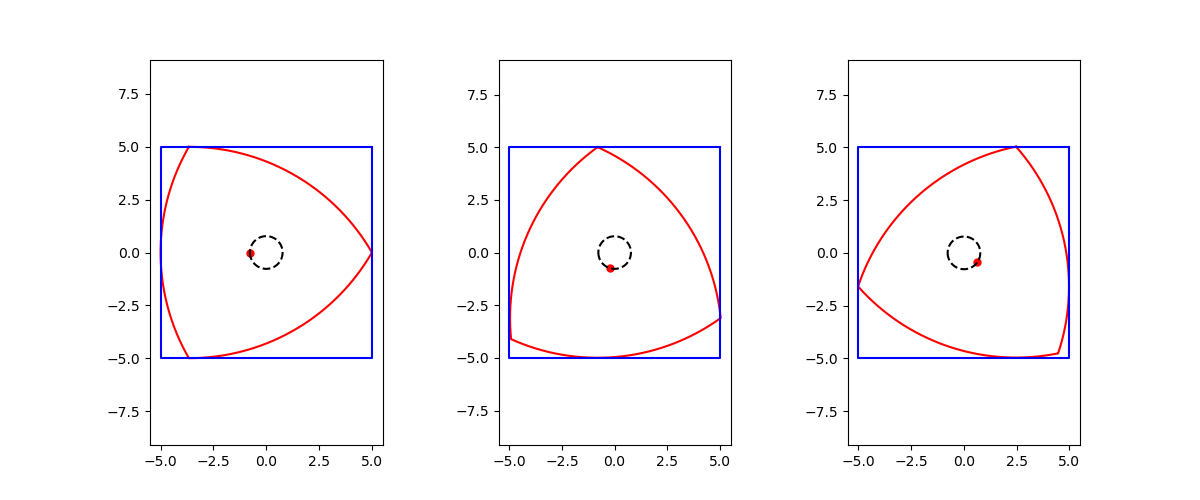

In [26]:
plt.figure(figsize = (12, 5))
plt.subplots_adjust(wspace = 0.5)

plt.subplot(1,3,1)
draw_frame(r = r, N_frames = N_frames)
plt.subplot(1,3,2)
draw_frame(r = r, N_frames = N_frames, frame = 20)
plt.subplot(1,3,3)
draw_frame(r = r, N_frames = N_frames, frame = 40)


### Анимация качения треугольника Рело против часовой стрелки

Реализуйте анимацию качения треугольника Рело против часовой стрелки:

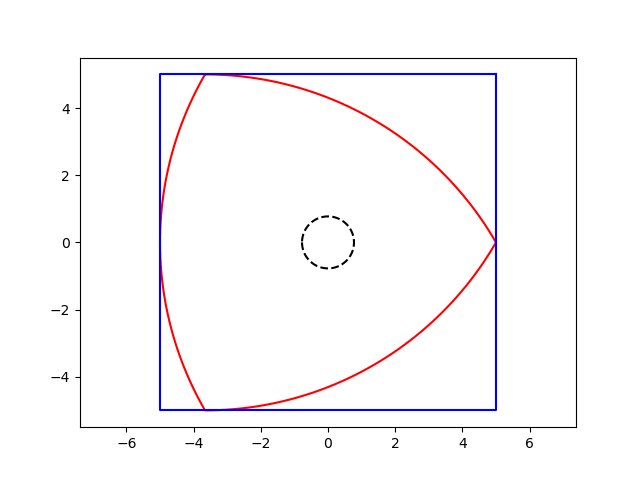

In [27]:
fig1 = plt.figure()
ax1 = plt.axes()


def init():
    global line, reloTriangle, relo_matrix, center_frame, rotate_matrix, theta
    
    #Создаем переменные;
    n, N = 3, 100
    r, N_frames = 10., 100
    center = np.array([0., 0.]) 
    
    #Анонимную функцию поворота матрицы на угол theta;
    rotate_matrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
                                         [-np.sin(theta), np.cos(theta)]])
    
    #Создаем матрицу координат точек сторон правильного треугольника Рело;
    relo_matrix = relo.regular_polygon_Relo(n, center, r, N)
    
    #Создаем матрицу координат вершин квадрата;
    angleList = np.arange(0, 2 * np.pi, np.pi / 2)
    square = center + r * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                          np.sign(np.sin(angleList + np.pi / 4))])
    square = np.vstack([square, square[0]])

    #Определяем сдвиг и создаем матрицу координат окружности;
    shift = np.array([r * 0.5 * (1 / np.sin(np.pi / n) - 1), 0])
    t_center = np.linspace(-np.pi, np.pi, N_frames)
    center_frame = shift[0] * np.transpose([np.cos(t_center), np.sin(t_center)])
    
    #Создаем матрицу качения треугольника Рело;
    theta = np.linspace(0, 2 * np.pi / 3, N_frames)
    matrix = rotate_matrix(theta[0])
    relo_matrixChanged = (np.array([np.dot(matrix,row) for row in relo_matrix]) 
                         + center_frame[0])
    
    #Отображаем фигуры в одной графической области;
    ax1.clear()
    
    reloTriangle, = ax1.plot(relo_matrixChanged[:, 0], relo_matrixChanged[:, 1], 'r-', markersize = 15)
    ax1.plot(square[:, 0], square[:, 1], 'b-')
    ax1.plot(center_frame[:, 0], center_frame[:, 1], 'k--')
    line, = ax1.plot([], [],'r.', markersize = 10)
    
    ax1.axis('equal')
    

def atFrame(frame):
    matrix = rotate_matrix(theta[frame])
    relo_matrixChanged = (np.array([np.dot(matrix,row) for row in relo_matrix]) 
                         + center_frame[frame])
    
    reloTriangle.set_data(relo_matrixChanged[:, 0], relo_matrixChanged[:, 1])
    line.set_data([center_frame[frame, 0]], [center_frame[frame, 1]])

init()

FuncAnimation(fig1, atFrame, frames = len(center_frame), init_func = init, repeat = False, interval = 20)

In [28]:
plt.close('all')